# Mixture Gaussians
Vamos aplicar o modelo probabilístico **Mixture Gaussians** para achar clusters
$$
    \ln p(X|\mu, \Sigma, \pi) = \sum_{n=1}^N \ln \{ \sum_{k=1}^K \pi_k \mathcal{N}(x_n|\mu_k, \Sigma_k) \}
$$

## Configuração
Importando bibliotecas necessárias e configuração para utilização de placa de vídeo (se possível)

In [9]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import os
from typing import Callable
import torch.nn as nn
from torch.distributions import MultivariateNormal
import sys
from pathlib import Path

root = Path().resolve().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## Dados
Importando os dados e fazendo visualização inicial. Dados disponíveis [aqui](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/geyser.csv)

In [10]:
data = pd.read_csv(os.path.join(root, 'data', 'geyser.csv'))

In [11]:
data.head()

,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long


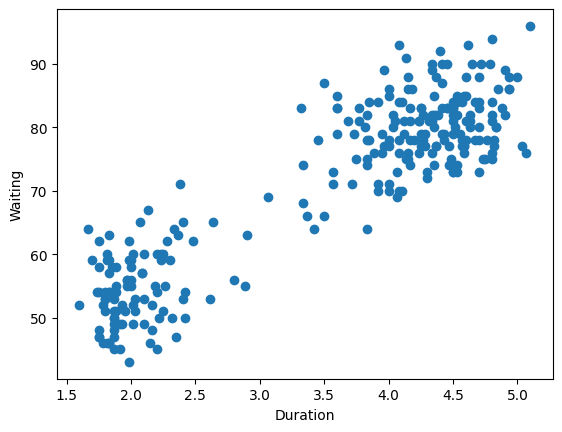

In [12]:
plt.plot(data['duration'], data['waiting'], 'o')
plt.xlabel('Duration')
plt.ylabel('Waiting')
plt.show()

In [13]:
# Montando o dataset, colocando com o buffer da placa de vídeo e removendo a coluna de tipo (vamos prever com GMM)
X = torch.tensor(data.drop(columns=['kind']).values, device=device, dtype=torch.float32)

## Modelo

In [ ]:
from typing import Callable
import torch
import torch.nn as nn
from torch.distributions import MultivariateNormal


class MixtureGaussians(nn.Module):
    def __init__(
        self,
        k: int,
        d: int,
        convergence_criterium: Callable[[torch.Tensor, torch.Tensor], bool],
        max_iterations: int = 1000,
        device=torch.device('cpu')
    ):
        """Mixture of Gaussians model

        Args:
            k (int): Number of Gaussian components in the mixture.
            d (int): Dimensionality of the data.
            convergence_criterium (Callable[[torch.Tensor, torch.Tensor], bool]): Function that
            receives 2 tensors as parameters, if the function returns True, is because the two tensors are
            close enough to consider that they converged. If it returns False, they are not close enough
            to consider to be converged
        """
        super().__init__()

        self.k = k
        self.d = d
        self.device = device
        self.convergence_criterium = convergence_criterium
        self.max_iterations = max_iterations


        # Initializing the parameters of the mixture of Gaussians

        # Means of the Gaussians
        self.mu = torch.randn(k, d, device=self.device)
        # Precision matrices (inverse of covariance) of the Gaussians
        self.covariances = torch.eye(d, device=self.device).unsqueeze(0).repeat(k, 1, 1)  # (K, D, D)
        # Adding a small value to the diagonal for numerical stability
        
        # Mixing coefficients (weights) for each Gaussian component
        self.pi = torch.ones(k, device=self.device) / k

    
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """Computes the log-likelihood of the data under the mixture of Gaussians model.

        Args:
            x (torch.Tensor): Input data of shape (n_samples, d).
        Returns:
            torch.Tensor: Log-likelihood of the data under the model.
        """
        N, _ = X.shape

        indices = torch.randperm(N)[:self.k]
        self.mu = X[indices].clone()  # (K, D)
        
        if self.d != X.shape[1]:
            raise ValueError(f"Input data must have dimensionality {self.d}, but got {X.shape[1]}")
        
        # Criteriums for MEANS, COVARIANCES and PROBABILITIES
        previous = [
            self.mu.clone(),
            self.covariances.clone(),
            self.pi.clone()
        ]
        criteriums = [
            False,
            False,
            False
        ]

        for _ in range(self.max_iterations):
            # Step E
            log_probs = []
            for k in range(self.k):
                dist = MultivariateNormal(loc=self.mu[k], covariance_matrix=self.covariances[k])
                log_probs.append(dist.log_prob(X))  # (N,)

            log_probs = torch.stack(log_probs, dim=1)  # (N, K)

            log_pi = torch.log(self.pi)
            log_weighted = log_pi + log_probs

            log_denom = torch.logsumexp(log_weighted, dim=1, keepdim=True)  # (N, 1)
            log_r = log_weighted - log_denom  # (N, K)

            r = log_r.exp()  # (N, K)

            # Step M
            Ns = r.sum(dim=0)  # (K,)
            
            self.mu = (r.T @ X) / Ns.unsqueeze(1)

            eps = 1e-6

            for k in range(self.k):
                diff = X - self.mu[k]                         # (N, D)
                weighted = r[:, k].unsqueeze(1) * diff        # (N, D)
                self.covariances[k] = (weighted.T @ diff) / Ns[k] + eps * torch.eye(self.d, device=self.device)
            
            self.pi = Ns / N

            # Criterium step
            criteriums[0] = self.convergence_criterium(self.mu, previous[0])
            criteriums[1] = self.convergence_criterium(self.covariances, previous[1])
            criteriums[2] = self.convergence_criterium(self.pi, previous[2])

            if sum(criteriums) == 3:
                break
    
    def log_likelihood(self, X: torch.Tensor) -> torch.Tensor:
        """Computes the log-likelihood of the data under the mixture of Gaussians model.

        Args:
            X (torch.Tensor): Input data of shape (n_samples, d).
        Returns:
            torch.Tensor: Log-likelihood scalar.
        """
        log_probs = []
        for k in range(self.k):
            dist = MultivariateNormal(loc=self.mu[k], covariance_matrix=self.covariances[k])
            log_probs.append(dist.log_prob(X))  # (N,)

        log_probs = torch.stack(log_probs, dim=1)  # (N, K)

        log_pi = torch.log(self.pi)
        log_weighted = log_pi + log_probs  # (N, K)

        # log p(x_n) = log sum_k pi_k * N_k  →  logsumexp over K
        log_px = torch.logsumexp(log_weighted, dim=1)  # (N,)

        # soma sobre todos os pontos
        return log_px.sum()


## Treinamento

In [15]:
ks = [1, 2, 3, 4, 5]
models = []

def convergence_criterium(old_params: torch.Tensor, new_params: torch.Tensor) -> bool:
    return torch.norm(new_params - old_params) < 1e-4

for k in ks:
    model = MixtureGaussians(k=k, d=X.shape[1], device=device, convergence_criterium=convergence_criterium)
    model.forward(X)
    models.append(model)

In [16]:
def BIC(model: MixtureGaussians, X: torch.Tensor) -> float:
    """
    Bayesian Information Criterion for model selection.

    Args:
        model (MixtureGaussians): The fitted mixture of Gaussians model.
        X (torch.Tensor): The data used to fit the model.

    Returns:
        float: The BIC score for the model.
    """
    N, D = X.shape
    K = model.k
    log_likelihood = model.log_likelihood(X).item()
    num_params = K * D + K - 1 + K*(D * (D + 1) // 2)  # K means + K-1 mixing coefficients + K covariance matrices
    bic_score = -2 * log_likelihood + num_params * torch.log(torch.tensor(N)).item()
    return bic_score

In [17]:
# Selecting the best model based on BIC
bic_scores = [BIC(model, X) for model in models]
best_k = ks[bic_scores.index(min(bic_scores))]
print(f"Best number of components according to BIC: {best_k}")

Best number of components according to BIC: 2


In [18]:
# Parameters of the best model
best_model = models[ks.index(best_k)]
print(f"Means:\n{best_model.mu}")
print(f"Covariances:\n{best_model.covariances}")
print(f"Mixing Coefficients:\n{best_model.pi}")

Means:
tensor([[ 4.2897, 79.9681],
        [ 2.0364, 54.4785]], device='cuda:0')
Covariances:
tensor([[[ 0.1700,  0.9406],
         [ 0.9406, 36.0462]],

        [[ 0.0692,  0.4352],
         [ 0.4352, 33.6973]]], device='cuda:0')
Mixing Coefficients:
tensor([0.6441, 0.3559], device='cuda:0')


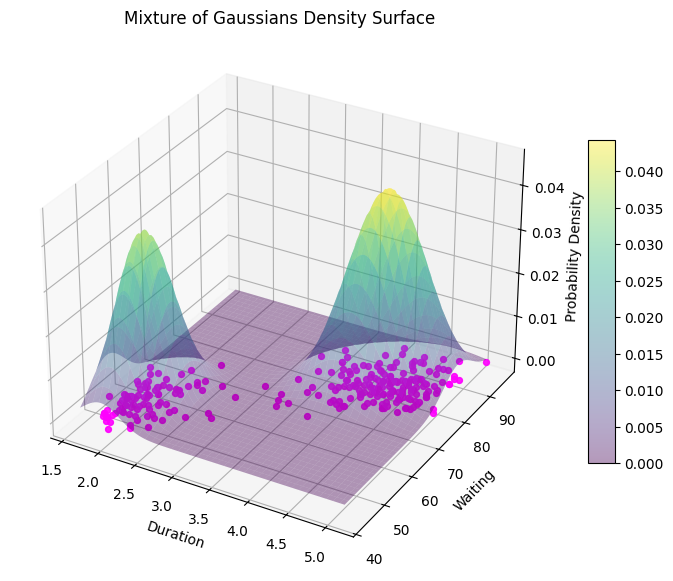

In [19]:
# 3D surface of the mixture density over the feature space
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm

# Move params to CPU for plotting
mu = best_model.mu.detach().cpu()
covs = best_model.covariances.detach().cpu()
pis = best_model.pi.detach().cpu()

# Build grid from data range
X_cpu = X.detach().cpu().numpy()
x_min, x_max = X_cpu[:, 0].min(), X_cpu[:, 0].max()
y_min, y_max = X_cpu[:, 1].min(), X_cpu[:, 1].max()
gx = np.linspace(x_min, x_max, 120)
gy = np.linspace(y_min, y_max, 120)
XX, YY = np.meshgrid(gx, gy)
grid = np.column_stack([XX.ravel(), YY.ravel()])

# Compute mixture density on the grid
grid_t = torch.tensor(grid, dtype=torch.float32)
K = best_model.k
D = grid_t.shape[1]
norm_const = (2 * np.pi) ** (D / 2)
dens = torch.zeros(grid_t.shape[0], dtype=torch.float32)

for k in range(K):
    diff = grid_t - mu[k]
    cov = covs[k]
    inv_cov = torch.linalg.inv(cov)
    det_cov = torch.linalg.det(cov)
    exponent = -0.5 * torch.sum((diff @ inv_cov) * diff, dim=1)
    comp = torch.exp(exponent) / (norm_const * torch.sqrt(det_cov))
    dens += pis[k] * comp

ZZ = dens.reshape(XX.shape).numpy()

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(XX, YY, ZZ, cmap=cm.viridis, linewidth=0, antialiased=True, alpha=0.4)

# Scatter data points on the horizontal plane (z=0)
z0 = np.zeros_like(X_cpu[:, 0])
ax.scatter(X_cpu[:, 0], X_cpu[:, 1], z0, color='#ff00ff', s=18, alpha=0.9, depthshade=False)

ax.set_xlabel('Duration')
ax.set_ylabel('Waiting')
ax.set_zlabel('Probability Density')
ax.set_title('Mixture of Gaussians Density Surface')
fig.colorbar(surf, shrink=0.6, aspect=12)
plt.show()